## DoE (Design of Experiment)

Is a structured, statistical approach for planning, conducting, and analyzing controlled tests to evaluate how multiple input variables (factors) affect a specific output (response). By changing factors simultaneously, it identifies critical interactions, optimizes processes, and improves quality while reducing the number of experimental runs needed.

Also we have Output (Y) in our case we need predict or improve the geometry in our estrator. The features (X) are the params that i can changing simultaneously to check the output

* Purpose: Used for screening (identifying critical factors), modeling (finding relationships), and optimization (finding best settings).
* Methodology: Involves purposeful, simultaneous changes to inputs rather than changing one factor at a time (OFAT).
* Common Techniques: Includes Full Factorial (testing all combinations) and Fractional Factorial (testing a portion) designs.
* Application Areas: Widely used in manufacturing (e.g., injection molding), R&D, and chemical processes for quality control and efficiency.

To make this DoE we use a LHS (Latin HyperCube Sampling Method) this method purpose a recreation of inputs distribution through less samples. The key is stratification of the input probability distribution. Moreover we decide to use this method beacuse the tradicional DoE Factorial makes like 5⁶ experiments. And this is like 15.625 rehersals. And to a CFD Software are too long to process. So it almost to talk dificult things go to hands-on

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import qmc
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Esto le dice a Python: "Sube un nivel en las carpetas (..) y mira ahí también"
ruta_raiz = os.path.abspath('..')
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# Ahora Python ya puede ver la carpeta 'scr'
from scr.LHS_Generator import LHS_DoE_Generation

In [5]:
if __name__ == "__main__":
    df_samplings = LHS_DoE_Generation(
        num_of_test=100,
        path_to_export='/home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/scripts/PNN/data_csv_LHS/LHS_samplings.csv',
        name_of_target='Power[Watts]',
        Atack_Angle=[10, 23],
        Output_Angle=[10, 23], 
        Number_of_blades=[4, 8],
        Blade_espesor=[8, 20],
        Atack_Border=[8, 20],
        Caudal=[100, 300],
        RPM=[0, 1000]
    )

Generated 100 samplings
File saved like /home/asus_juan/Documents/GitHub/Despliegue-modelo-ANN-Turbinas-Hidraulicas/scripts/PNN/data_csv_LHS/LHS_samplings.csv
First 5 rows generates 

   Atack_Angle  Output_Angle  Number_of_blades  Blade_espesor  Atack_Border  \
0       18.721        13.522             7.645         16.003         8.485   
1       16.662        12.060             6.945         17.890         9.299   
2       12.931        10.770             6.403         17.478        18.831   
3       22.684        22.245             6.326         11.952        19.931   
4       15.626        19.909             7.587         15.004        12.911   

    Caudal      RPM  Power[Watts]  
0  253.650  880.034           NaN  
1  201.501  230.721           NaN  
2  284.984  948.389           NaN  
3  153.730  164.414           NaN  
4  296.775  182.373           NaN  


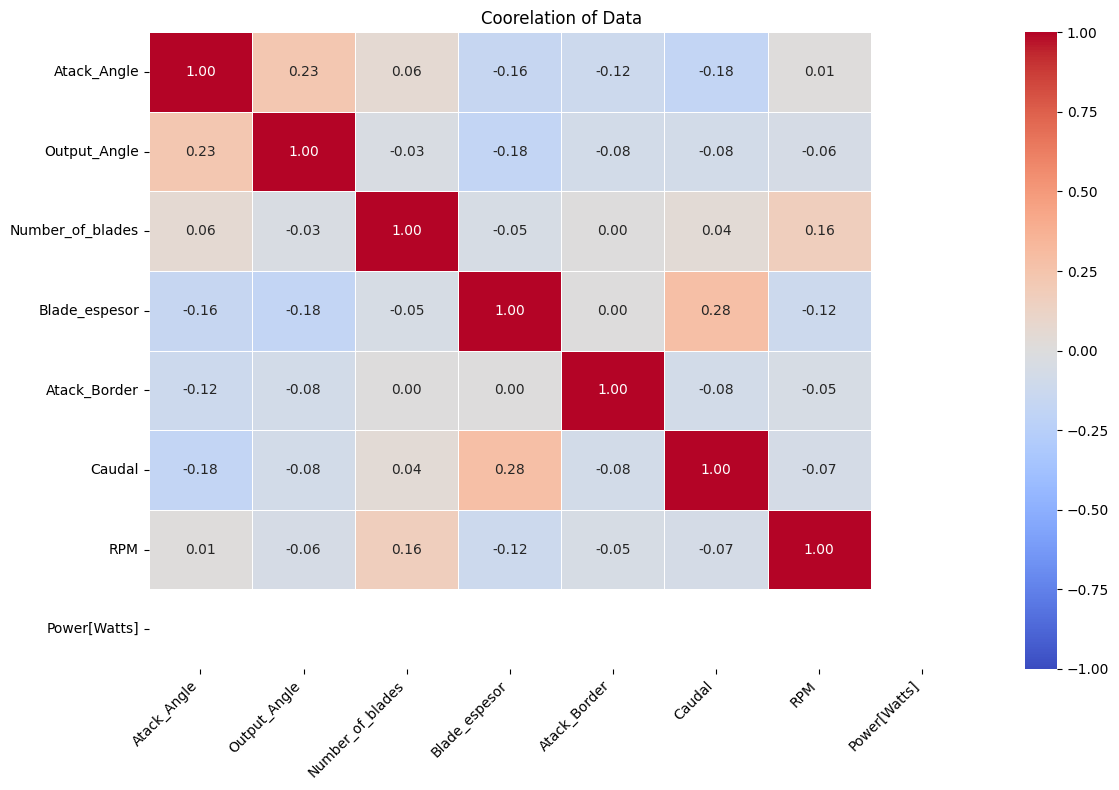

In [11]:
coor_matrix = df_samplings.corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    coor_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Coorelation of Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()